# Gradient Descent

Gradient descent is an iterative optimization algorithm that minimizes a function's value by repeatedly taking steps in the direction of the steepest descent, also known as the negative gradient. It's commonly used to train machine learning models by minimizing a cost function (the error between predicted and actual values), finding the optimal parameters (weights and biases) that result in the best model.

In [1]:
import os
import urllib.request
from urllib.parse import quote

BASE = "https://raw.githubusercontent.com/cienciadadesdsuab/DS26-27/main/Laboratoris/Session%204%20-%20Gradient%20Descent/"
os.makedirs("scratch", exist_ok=True)
files = [
    "gradient descent graph.jpg",
    "gradient descent types.jpg",
    "scratch/gradient_descent.py",
    "scratch/linear_algebra.py",
    "scratch/simple_linear_regression.py",
    "scratch/statistics.py",
]
for f in files:
    urllib.request.urlretrieve(BASE + quote(f), f)

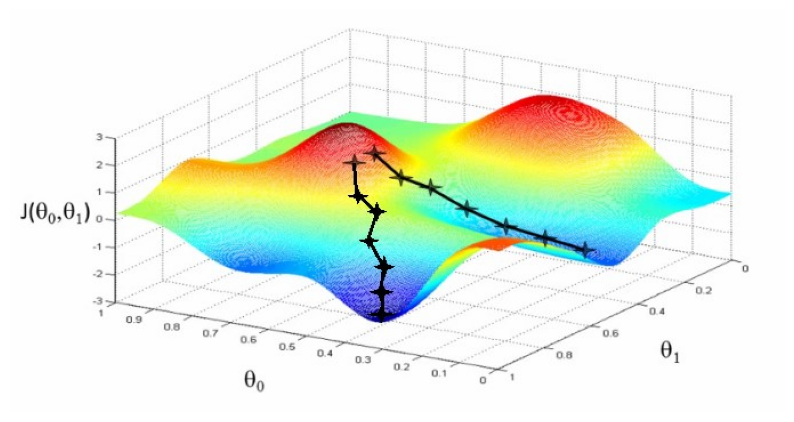

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
imagen1 = mpimg.imread('gradient descent graph.jpg')
plt.figure(figsize=(10, 8))
plt.imshow(imagen1)
plt.axis('off')
plt.show()


Batch Gradient Descent (BGD) and Stochastic Gradient Descent (SGD) are optimization agorithms that differ in how they update model weights: BGD uses the entire dataset for each update, leading to accurate but slow convergence, while SGD uses only one data point per update, resulting in fast but noise convergence

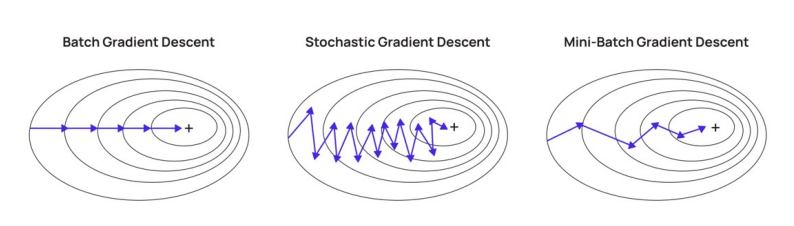

In [3]:
imagen2 = mpimg.imread('gradient descent types.jpg')
plt.figure(figsize=(10, 8))
plt.imshow(imagen2)
plt.axis('off')
plt.show()

## Math Formulas

 In linear regression, the model $h$ is a linear function of the input data ($x$, in our case the house size):

> $f_w(x) = w_0 + w_1 x$

For this we need to choose the parameters $w_i$ minimizing a cost function $J$ e.g. the average squared difference between the predictions ($f_w$) and the real prices ($y$) in our training data:

> $\hat{w} = \underset{w}{\text{minimize}} {1 \over 2m} \sum_{i=1}^m{(f_w(x^{(i)}) - y^{(i)})^2}$

where $(x^{(i)},y^{(i)})$ is the i-th training sample, and $m$ is the number of samples in our training set.

This optimization problem can be solved in different ways, in this example we are going to implement the Gradient Descent algorithm. In pseudo-code the Gradient Descent algorithm is formalized as follows:

repeat until convergence:

> {
>
> $w_j := w_j - \alpha \frac{\partial}{\partial w_j} J(w)$ (for all j)
>
> }

where $\alpha$ is the learning rate, and the partial derivative (the gradient) of the cost function is given by (generic expression):

> $\frac{\partial}{\partial w_j} J(w) = {1 \over m} \sum_{i=1}^m{(f_w(x^{(i)}) - y^{(i)}) x_j^{(i)}}$

In our case, the partial derivatives for $w_0$ and $w_1$ are:

> $\frac{\partial}{\partial w_0} J(w) = {1 \over m} \sum_{i=1}^m{(f_w(x^{(i)}) - y^{(i)})}$

> $\frac{\partial}{\partial w_1} J(w) = {1 \over m} \sum_{i=1}^m{(f_w(x^{(i)}) - y^{(i)}) x^{(i)}}$

## Steps to build the model

**1. Choose a model and a cost function:**  
Select a model that you want to optimize, such as linear regression, logistic regression, or a neural network.  
Choose a cost function that measures the difference between the predicted output and the actual output, such as mean squared error, cross-entropy loss, or binary log loss.  

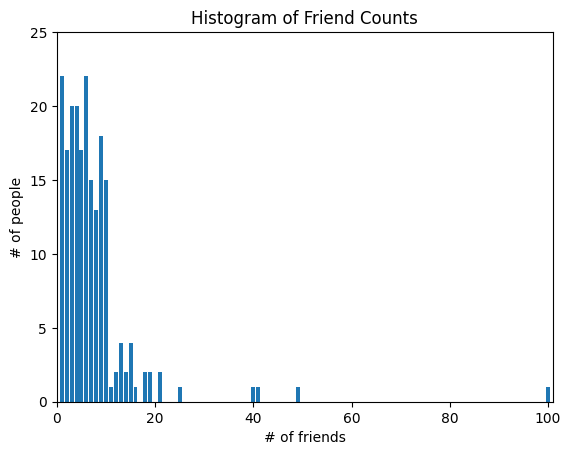

In [4]:
from scratch.linear_algebra import Vector
from scratch.statistics import num_friends_good, daily_minutes_good
from scratch.simple_linear_regression import predict, error
from scratch.gradient_descent import gradient_step
import math
import tqdm

def sum_of_sqerror (alpha: float, beta:float,x: Vector, y: Vector)-> float:
    return sum(error(alpha,beta,x_i,y_i)**2 for x_i,y_i in zip(x,y))

**2. Initialize the parameters:**

Set the initial values for the parameters that you want to optimize, such as the weights and biases of the model.

In [5]:
guess= [0, 0]
alpha,beta = guess
learning_rate= 0.00001
guess

[0, 0]

**3. Compute the gradient:**

Calculate the gradient of the cost function with respect to each parameter by taking the partial derivative of the cost function with respect to each parameter.

In [6]:
alpha,beta = guess
grad_a = sum(2*error(alpha,beta,x_i,y_i) for x_i,y_i in zip(num_friends_good,daily_minutes_good))
grad_b = sum(2*error(alpha,beta,x_i,y_i)*x_i for x_i,y_i in zip(num_friends_good,daily_minutes_good))
grad_a,grad_b

(-11840.3, -95748.26)

**4. Update the parameters:**

Adjust the parameters in the direction of the negative gradient by multiplying it with a learning rate, which controls the size of the update.

In [7]:
guess = gradient_step (guess, [grad_a,grad_b], -learning_rate)
guess

[0.11840300000000001, 0.9574826000000001]

**5. Repeat until convergence:**

Iterate the above three steps until the cost function converges to a minimum or a satisfactory threshold, such as a small change in the cost function between iterations.

In [8]:
history = []
with tqdm.trange(10000) as t:
    for _ in t:
        alpha,beta = guess
        grad_a = sum(error(alpha,beta,x_i,y_i) for x_i,y_i in zip(num_friends_good,daily_minutes_good))
        grad_b = sum(error(alpha,beta,x_i,y_i)*x_i for x_i,y_i in zip(num_friends_good,daily_minutes_good))
        guess = gradient_step (guess, [grad_a,grad_b], -learning_rate)
        history.append((alpha, beta, math.sqrt(sum_of_sqerror(alpha,beta,num_friends_good,daily_minutes_good)/len(num_friends_good))))

print ("final values of alpha and beta:", guess)
history[:30]

100%|██████████| 10000/10000 [00:02<00:00, 4774.69it/s]

final values of alpha and beta: [22.94508183495091, 0.904063787004842]


[(0.11840300000000001, 0.9574826000000001, 23.866113411035418),
 (0.163997684814, 1.266781743296, 21.94870050128616),
 (0.20518199637741544, 1.5212428029208056, 20.54303447724112),
 (0.24273042739599485, 1.730537173467535, 19.528474792114043),
 (0.27728088568677417, 1.9026306224226361, 18.805487154007817),
 (0.30935878199981004, 2.044084090985106, 18.295078650394668),
 (0.33939686976219835, 2.1603014462841585, 17.93680416046804),
 (0.36775158592645424, 2.2557335405354424, 17.68582339761026),
 (0.39471650998114877, 2.334046282752478, 17.509680995960647),
 (0.42053344935866244, 2.398259069683597, 17.385319303723254),
 (0.44540156984368134, 2.4508588033591967, 17.296579035538965),
 (0.4694849157620043, 2.493893800743513, 17.232245318729547),
 (0.492918603924628, 2.5290511416771824, 17.1845880313348),
 (0.5158139252208476, 2.557720375898885, 17.148304384574363),
 (0.5382625465051009, 2.5810459948302813, 17.119768694315066),
 (0.5603399714478647, 2.5999706495470116, 17.096507576129568),
 (0

Let´s see how the process looks like in 3d and 2d graphics:

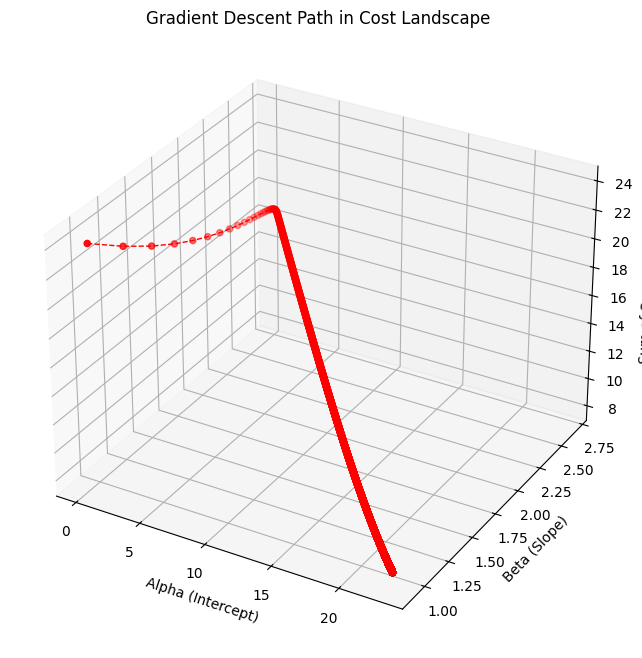

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
history = np.array(history)

alpha_hist = history[:, 0]
beta_hist = history[:, 1]
error_hist = history[:, 2]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(alpha_hist, beta_hist, error_hist, c='r', marker='o')
ax.plot(alpha_hist, beta_hist, error_hist, color='r', linestyle='--', linewidth=1)

ax.set_xlabel('Alpha (Intercept)')
ax.set_ylabel('Beta (Slope)')
ax.set_zlabel('Sum of Squared Error')
ax.set_title('Gradient Descent Path in Cost Landscape')

plt.show()

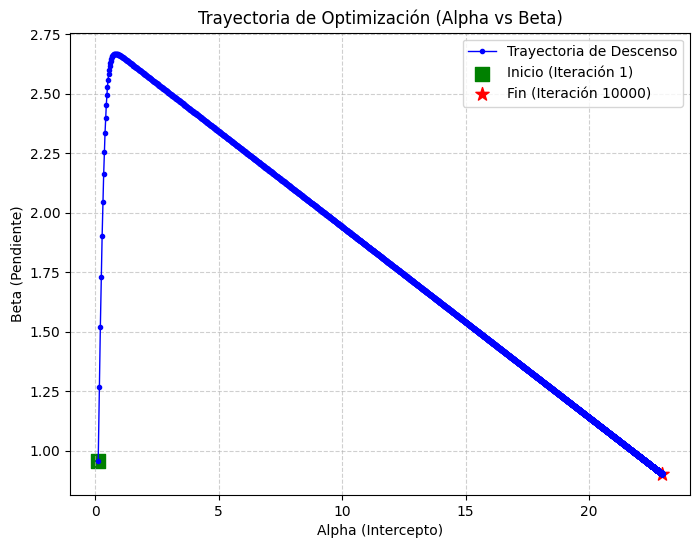

In [10]:
import numpy as np
import matplotlib.pyplot as plt

alpha_hist = history[:, 0]
beta_hist = history[:, 1]
plt.figure(figsize=(8, 6))
plt.plot(alpha_hist, beta_hist,
         color='blue',
         linestyle='-',
         marker='o',
         markersize=3,
         linewidth=1,
         label='Trayectoria de Descenso')

plt.scatter(alpha_hist[0], beta_hist[0],
            color='green',
            s=100,
            marker='s',
            label='Inicio (Iteración 1)')
plt.scatter(alpha_hist[-1], beta_hist[-1],
            color='red',
            s=100,
            marker='*',
            label='Fin (Iteración 10000)')


plt.title('Trayectoria de Optimización (Alpha vs Beta)')
plt.xlabel('Alpha (Intercepto)')
plt.ylabel('Beta (Pendiente)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# House Prices

During the previous lecture, we used a running example of house prices. This dataset is known as the "house prices" dataset. The task to be done is to predict the price of a house given some 'features' of the house. Our input data comprises two features per sample (size of the house, and number of rooms), while the output data is the price of each sample.

Here is the data:

| Size (square feet) | Rooms | Price (USD) |Size (square feet) | Rooms | Price (USD) |Size (square feet) | Rooms | Price (USD) |Size (square feet) | Rooms | Price (USD) |
|:------ |:----|:----------|:------ |:----|:----------|:------ |:----|:----------|:------ |:----|:----------|
| 2104.0 | 3.0 |  **399900.0** | 1890.0 | 3.0 |  **329999.0** | 3890.0 | 3.0 |  **573900.0** | 1239.0 | 3.0 |  **229900.0** |
| 1600.0 | 3.0 |  **329900.0** | 4478.0 | 5.0 |  **699900.0** | 1100.0 | 3.0 |  **249900.0** | 2132.0 | 4.0 |  **345000.0** |
| 2400.0 | 3.0 |  **369000.0** | 1268.0 | 3.0 |  **259900.0** | 1458.0 | 3.0 |  **464500.0** | 4215.0 | 4.0 |  **549000.0** |
| 1416.0 | 2.0 |  **232000.0** | 2300.0 | 4.0 |  **449900.0** | 2526.0 | 3.0 |  **469000.0** | 2162.0 | 4.0 |  **287000.0** |
| 3000.0 | 4.0 |  **539900.0** | 1320.0 | 2.0 |  **299900.0** | 2200.0 | 3.0 |  **475000.0** | 1664.0 | 2.0 |  **368500.0** |
| 1985.0 | 4.0 |  **299900.0** | 1236.0 | 3.0 |  **199900.0** | 2637.0 | 3.0 |  **299900.0** | 2238.0 | 3.0 |  **329900.0** |
| 1534.0 | 3.0 |  **314900.0** | 2609.0 | 4.0 |  **499998.0** | 1839.0 | 2.0 |  **349900.0** | 2567.0 | 4.0 |  **314000.0** |
| 1427.0 | 3.0 |  **198999.0** | 3031.0 | 4.0 |  **599000.0** | 1000.0 | 1.0 |  **169900.0** | 1200.0 | 3.0 |  **299000.0** |
| 1380.0 | 3.0 |  **212000.0** | 1767.0 | 3.0 |  **252900.0** | 2040.0 | 4.0 |  **314900.0** | 852.0  | 2.0 |  **179900.0** |
| 1494.0 | 3.0 |  **242500.0** | 1888.0 | 2.0 |  **255000.0** | 3137.0 | 3.0 |  **579900.0** | 1852.0 | 4.0 |  **299900.0** |
| 1940.0 | 4.0 |  **239999.0** | 1604.0 | 3.0 |  **242900.0** | 1811.0 | 4.0 |  **285900.0** | 1203.0 | 3.0 |  **239500.0** |
| 2000.0 | 3.0 |  **347000.0** | 1962.0 | 4.0 |  **259900.0** | 1437.0 | 3.0 |  **249900.0** |

Let's first get them into Python. For simplification we are going to use only one feature for the time being - the size of the house.

In [11]:
size = [2104., 1600., 2400., 1416., 3000., 1985., 1534., 1427., 1380.,
       1494., 1940., 2000., 1890., 4478., 1268., 2300., 1320., 1236.,
       2609., 3031., 1767., 1888., 1604., 1962., 3890., 1100., 1458.,
       2526., 2200., 2637., 1839., 1000., 2040., 3137., 1811., 1437.,
       1239., 2132., 4215., 2162., 1664., 2238., 2567., 1200.,  852.,
       1852., 1203.]

rooms = [3., 3., 3., 2., 4., 4., 3., 3., 3., 3., 4., 3., 3., 5., 3., 4., 2.,
       3., 4., 4., 3., 2., 3., 4., 3., 3., 3., 3., 3., 3., 2., 1., 4., 3.,
       4., 3., 3., 4., 4., 4., 2., 3., 4., 3., 2., 4., 3.]

price = [399900., 329900., 369000., 232000., 539900., 299900., 314900.,
       198999., 212000., 242500., 239999., 347000., 329999., 699900.,
       259900., 449900., 299900., 199900., 499998., 599000., 252900.,
       255000., 242900., 259900., 573900., 249900., 464500., 469000.,
       475000., 299900., 349900., 169900., 314900., 579900., 285900.,
       249900., 229900., 345000., 549000., 287000., 368500., 329900.,
       314000., 299000., 179900., 299900., 239500.]

In [21]:
def GradientDescent(x, y, max_iterations=10, learning_rate=0.00000001):
    w0, w1 = 0.0, 0.0
    sample_count = len(x)

    for _ in range(max_iterations):

      errors = [w0 + w1 * x_i - y_i for x_i, y_i in zip(x, y)]
      grad_w0 = sum(2 * error for error in errors) / sample_count
      grad_w1 = sum(2 * error * x_i for error, x_i in zip(errors, x)) / sample_count
      w0 = w0 - (learning_rate * grad_w0)
      w1 -= learning_rate * grad_w1

    return [w0, w1]

w = GradientDescent(size, price)

print(w)

[0.046359859834436086, 102.67042784169712]
